# Phase 1: Core 2×2 Comparison - SH + Learned Activations

**Goal**: Test the core hypothesis from Dan's roadmap

## The 2×2 Grid

| | SIREN | Learned Acts (RFF/Spline) |
|---|-------|--------------|
| **Raw coords** | Baseline: SIREN discovers frequencies | Test: Can learned acts do it too? |
| **SH features** | Baseline: SH provides frequencies | Test: Better nonlinearity than SIREN? |

## Win Conditions
1. **If Raw + Learned ≈ Raw + SIREN**: Learned acts can discover frequencies!
2. **If SH + Learned > SH + SIREN**: Better nonlinearity confirmed!

## Results from Notebook 15
- **Raw + RFF**: R² = 0.733 (our models don't use SH yet)
- **SH(L=10) + SIREN**: R² = 0.704 (SatCLIP baseline)
- **Gap**: +2.9% without even using SH features!

**Key question**: Can we get even better by combining SH + RFF?

In [1]:
# Setup
import os
import sys

if 'COLAB_GPU' in os.environ:
    !rm -rf sample_data .config satclip gpw_data 2>/dev/null
    !git clone https://github.com/1hamzaiqbal/satclip.git
    !pip install lightning torchgeo huggingface_hub rasterio --quiet
    sys.path.append('./satclip/satclip')
else:
    sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'satclip'))

Cloning into 'satclip'...
remote: Enumerating objects: 517, done.
remote: Counting objects: 100% (196/196), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 517 (delta 164), reused 151 (delta 142), pack-reused 321 (from 2)
Receiving objects: 100% (517/517), 82.17 MiB | 49.79 MiB/s, done.
Resolving deltas: 100% (267/267), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.9/243.9 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.3/859.3 kB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.8 MB/s eta 0:00:00
   ━━━━━

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
GPW_DIR = './gpw_data'
os.makedirs(GPW_DIR, exist_ok=True)

print("Extracting GPW data...")
with zipfile.ZipFile('/content/drive/MyDrive/grad/learned_activations/dataverse_files.zip', 'r') as z:
    z.extractall(GPW_DIR)

with zipfile.ZipFile(f'{GPW_DIR}/gpw-v4-population-density-rev11_2020_15_min_tif.zip', 'r') as z:
    z.extractall(GPW_DIR)
print("Done!")

Mounted at /content/drive
Extracting GPW data...
Done!


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import time
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge
from huggingface_hub import hf_hub_download
import positional_encoding as PE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


---
## Activation Classes

In [4]:
# =============================================================================
# RFF ACTIVATION
# =============================================================================

class RFFActivation(nn.Module):
    """Random Fourier Features activation."""
    def __init__(self, n_features=25, max_freq=10.0, learnable_freq=False, freq_init='linear'):
        super().__init__()
        self.n_features = n_features
        self.learnable_freq = learnable_freq

        # Frequency initialization
        if freq_init == 'linear':
            freqs = torch.linspace(0.1, max_freq, n_features)
        elif freq_init == 'log':
            freqs = torch.logspace(-2, np.log10(max_freq), n_features)
        elif freq_init == 'random':
            freqs = torch.rand(n_features) * max_freq
        else:
            raise ValueError(f"Unknown freq_init: {freq_init}")

        if learnable_freq:
            self.freqs = nn.Parameter(freqs)
        else:
            self.register_buffer('freqs', freqs)

        self.sin_coeff = nn.Parameter(torch.randn(n_features) * 0.1)
        self.cos_coeff = nn.Parameter(torch.randn(n_features) * 0.1)
        self.scale = nn.Parameter(torch.ones(1))
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        wx = x.unsqueeze(-1) * self.freqs
        sin_part = (torch.sin(wx) * self.sin_coeff).sum(-1)
        cos_part = (torch.cos(wx) * self.cos_coeff).sum(-1)
        return self.scale * (sin_part + cos_part) + self.bias

    def num_params(self):
        return sum(p.numel() for p in self.parameters())


# =============================================================================
# SPLINE ACTIVATION
# =============================================================================

class SplineActivation(nn.Module):
    """Cubic B-spline activation with learnable control points."""
    def __init__(self, n_knots=10, input_range=(-3.0, 3.0), init='relu'):
        super().__init__()
        self.n_knots = n_knots
        self.input_range = input_range

        knot_x = torch.linspace(input_range[0], input_range[1], n_knots)
        self.register_buffer('knot_x', knot_x)

        if init == 'relu':
            knot_y = torch.relu(knot_x)
        elif init == 'linear':
            knot_y = knot_x.clone()
        elif init == 'zero':
            knot_y = torch.zeros(n_knots)
        else:
            knot_y = torch.randn(n_knots) * 0.1

        self.knot_y = nn.Parameter(knot_y)

    def forward(self, x):
        x_clamped = torch.clamp(x, self.input_range[0], self.input_range[1])
        x_norm = (x_clamped - self.input_range[0]) / (self.input_range[1] - self.input_range[0])
        x_idx = x_norm * (self.n_knots - 1)

        idx_low = torch.floor(x_idx).long()
        idx_high = torch.clamp(idx_low + 1, max=self.n_knots - 1)
        idx_low = torch.clamp(idx_low, max=self.n_knots - 1)

        weight = x_idx - idx_low.float()
        y_low = self.knot_y[idx_low]
        y_high = self.knot_y[idx_high]

        return y_low + weight * (y_high - y_low)

    def num_params(self):
        return self.knot_y.numel()


# =============================================================================
# SIREN ACTIVATION (from SatCLIP)
# =============================================================================

class SirenLayer(nn.Module):
    """SIREN layer from SatCLIP."""
    def __init__(self, dim_in, dim_out, w0=1.0, is_first=False):
        super().__init__()
        self.dim_in = dim_in
        self.w0 = w0
        self.is_first = is_first

        self.linear = nn.Linear(dim_in, dim_out)
        self._init_weights()

    def _init_weights(self):
        if self.is_first:
            bound = 1.0 / self.dim_in
        else:
            bound = np.sqrt(6.0 / self.dim_in) / self.w0

        self.linear.weight.data.uniform_(-bound, bound)
        if self.linear.bias is not None:
            self.linear.bias.data.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.w0 * self.linear(x))

print("Activation classes loaded!")

Activation classes loaded!


---
## Encoder Architectures

In [5]:
# =============================================================================
# UNIVERSAL ENCODER (handles Raw or SH input + any activation)
# =============================================================================

class UniversalEncoder(nn.Module):
    """
    Universal encoder that supports:
    - Input: Raw coords (2D) or SH features (auto-detected dimension)
    - Activation: RFF, Spline, SIREN, or ReLU
    """
    def __init__(self, input_type='raw', sh_legendre_polys=None,
                 activation_type='rff', activation_kwargs=None,
                 n_layers=3, hidden_dim=256, output_dim=256):
        super().__init__()
        self.input_type = input_type
        self.activation_type = activation_type

        # Input encoding
        if input_type == 'raw':
            self.posenc = None
            input_dim = 2
        elif input_type == 'sh':
            assert sh_legendre_polys is not None
            self.posenc = PE.SphericalHarmonics(
                legendre_polys=sh_legendre_polys,
                harmonics_calculation='analytic'
            )
            # Auto-detect SH output dimension by running a test forward pass
            with torch.no_grad():
                test_coords = torch.zeros(1, 2)
                test_output = self.posenc(test_coords)
                input_dim = test_output.shape[1]
            print(f"  SH(L={sh_legendre_polys}) output dim: {input_dim}")
        else:
            raise ValueError(f"Unknown input_type: {input_type}")

        if activation_kwargs is None:
            activation_kwargs = {}

        # Build network
        dims = [input_dim] + [hidden_dim] * n_layers + [output_dim]

        if activation_type == 'siren':
            # SIREN: Special initialization, w0_initial=30 for first, w0=1 for rest
            self.layers = nn.ModuleList()
            for i in range(len(dims) - 1):
                is_first = (i == 0)
                w0 = 30.0 if is_first else 1.0
                if i < len(dims) - 2:
                    # Hidden layers: SIREN
                    self.layers.append(SirenLayer(dims[i], dims[i+1], w0=w0, is_first=is_first))
                else:
                    # Last layer: Linear (no activation)
                    linear = nn.Linear(dims[i], dims[i+1])
                    # SIREN init for last layer
                    bound = np.sqrt(6.0 / dims[i]) / 1.0
                    linear.weight.data.uniform_(-bound, bound)
                    if linear.bias is not None:
                        linear.bias.data.uniform_(-bound, bound)
                    self.layers.append(linear)
            self.activations = None

        elif activation_type in ['rff', 'spline']:
            # Learned activations
            self.linears = nn.ModuleList([
                nn.Linear(dims[i], dims[i+1])
                for i in range(len(dims) - 1)
            ])

            act_class = RFFActivation if activation_type == 'rff' else SplineActivation
            self.activations = nn.ModuleList([
                act_class(**activation_kwargs)
                for _ in range(n_layers)
            ])

            # Kaiming init
            for linear in self.linears:
                nn.init.kaiming_normal_(linear.weight)
                nn.init.zeros_(linear.bias)

        elif activation_type == 'relu':
            # Standard ReLU
            layers = []
            for i in range(len(dims) - 1):
                layers.append(nn.Linear(dims[i], dims[i+1]))
                if i < len(dims) - 2:
                    layers.append(nn.ReLU())
            self.net = nn.Sequential(*layers)
            for m in self.modules():
                if isinstance(m, nn.Linear):
                    nn.init.kaiming_normal_(m.weight)
                    nn.init.zeros_(m.bias)

        else:
            raise ValueError(f"Unknown activation_type: {activation_type}")

    def forward(self, coords):
        # Input encoding
        if self.input_type == 'raw':
            # Normalize raw coords to [-1, 1]
            x = coords / torch.tensor([180., 90.], device=coords.device)
        else:  # 'sh'
            x = self.posenc(coords)

        # Forward through network
        if self.activation_type == 'siren':
            for layer in self.layers:
                x = layer(x)
        elif self.activation_type in ['rff', 'spline']:
            for i, (linear, act) in enumerate(zip(self.linears[:-1], self.activations)):
                x = act(linear(x))
            x = self.linears[-1](x)  # Last layer, no activation
        else:  # 'relu'
            x = self.net(x)

        return x

    def num_params(self):
        return sum(p.numel() for p in self.parameters())

print("Universal encoder loaded!")

Universal encoder loaded!


---
## Data Loading

In [6]:
# Load population data (15-min resolution only)
Image.MAX_IMAGE_PIXELS = None

print("Loading population data...")
img = Image.open(f'{GPW_DIR}/gpw_v4_population_density_rev11_2020_15_min.tif')
pop_data = np.array(img)
h, w = pop_data.shape
lons = np.linspace(-180 + 180/w, 180 - 180/w, w)
lats = np.linspace(90 - 90/h, -90 + 90/h, h)
print(f"Shape: {pop_data.shape}")

# Spatial blocking
def sample_blocked(data, lons, lats, n_samples=15000, grid_size=5.0, test_ratio=0.3, seed=42):
    np.random.seed(seed)
    valid = data > -1e30

    n_lon = int(360 / grid_size)
    n_lat = int(180 / grid_size)
    n_cells = n_lon * n_lat

    test_cells = set(np.random.choice(n_cells, int(n_cells * test_ratio), replace=False))

    valid_idx = np.where(valid)
    n_valid = len(valid_idx[0])
    sample_idx = np.random.choice(n_valid, min(n_samples, n_valid), replace=False)

    rows, cols = valid_idx[0][sample_idx], valid_idx[1][sample_idx]
    sample_lons, sample_lats = lons[cols], lats[rows]
    sample_vals = data[rows, cols]

    train_mask = []
    for lon, lat in zip(sample_lons, sample_lats):
        cell = int((lat + 90) / grid_size) * n_lon + int((lon + 180) / grid_size)
        cell = min(cell, n_cells - 1)
        train_mask.append(cell not in test_cells)
    train_mask = np.array(train_mask)

    coords = np.stack([sample_lons, sample_lats], axis=1)
    return coords[train_mask], sample_vals[train_mask], coords[~train_mask], sample_vals[~train_mask]

coords_train, vals_train, coords_test, vals_test = sample_blocked(pop_data, lons, lats)
print(f"Train: {len(coords_train)}, Test: {len(coords_test)}")

Loading population data...
Shape: (720, 1440)
Train: 10532, Test: 4468


---
## Training & Evaluation

In [7]:
class PopulationPredictor(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 1)
        )

    def forward(self, coords):
        return self.head(self.encoder(coords)).squeeze(-1)


def train_and_evaluate(name, encoder, coords_train, vals_train, coords_test, vals_test,
                      epochs=100, batch_size=256, lr=1e-3):
    """Train encoder and return results."""
    model = PopulationPredictor(encoder).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    train_X = torch.tensor(coords_train, dtype=torch.float32)
    train_y = torch.tensor(np.log1p(vals_train), dtype=torch.float32)
    test_X = torch.tensor(coords_test, dtype=torch.float32).to(device)
    test_y = torch.tensor(np.log1p(vals_test), dtype=torch.float32)

    loader = DataLoader(TensorDataset(train_X, train_y),
                       batch_size=batch_size, shuffle=True)

    start = time.time()
    best_r2 = -float('inf')

    for epoch in range(epochs):
        model.train()
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(model(X), y)
            loss.backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            pred = model(test_X).cpu().numpy()
        r2 = r2_score(test_y.numpy(), pred)
        best_r2 = max(best_r2, r2)

    train_time = time.time() - start
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return {
        'model': name,
        'r2': best_r2,
        'params': n_params,
        'efficiency': best_r2 / (n_params / 10000),
        'time': train_time,
    }

print("Functions loaded!")

Functions loaded!


---
## Phase 1 Experiments: The 2×2 Grid + Variants

In [8]:
print("="*80)
print("PHASE 1: CORE 2×2 COMPARISON")
print("="*80)

results = []

# ============================================================================
# ROW 1: RAW COORDINATES
# ============================================================================

print("\n" + "="*80)
print("RAW COORDINATES (2D)")
print("="*80)

# Raw + SIREN
print("\n[1/12] Raw + SIREN (SatCLIP baseline)...")
enc = UniversalEncoder(input_type='raw', activation_type='siren', n_layers=3)
res = train_and_evaluate('Raw + SIREN', enc, coords_train, vals_train, coords_test, vals_test)
results.append(res)
print(f"  R² = {res['r2']:.4f}, Params = {res['params']:,}")

# Raw + RFF (n=25)
print("\n[2/12] Raw + RFF (n=25)...")
enc = UniversalEncoder(input_type='raw', activation_type='rff',
                       activation_kwargs={'n_features': 25}, n_layers=3)
res = train_and_evaluate('Raw + RFF (n=25)', enc, coords_train, vals_train, coords_test, vals_test)
results.append(res)
print(f"  R² = {res['r2']:.4f}, Params = {res['params']:,}")

# Raw + RFF (n=50)
print("\n[3/12] Raw + RFF (n=50)...")
enc = UniversalEncoder(input_type='raw', activation_type='rff',
                       activation_kwargs={'n_features': 50}, n_layers=3)
res = train_and_evaluate('Raw + RFF (n=50)', enc, coords_train, vals_train, coords_test, vals_test)
results.append(res)
print(f"  R² = {res['r2']:.4f}, Params = {res['params']:,}")

# Raw + RFF (n=100)
print("\n[4/12] Raw + RFF (n=100)...")
enc = UniversalEncoder(input_type='raw', activation_type='rff',
                       activation_kwargs={'n_features': 100}, n_layers=3)
res = train_and_evaluate('Raw + RFF (n=100)', enc, coords_train, vals_train, coords_test, vals_test)
results.append(res)
print(f"  R² = {res['r2']:.4f}, Params = {res['params']:,}")

# Raw + Spline (k=10)
print("\n[5/12] Raw + Spline (k=10)...")
enc = UniversalEncoder(input_type='raw', activation_type='spline',
                       activation_kwargs={'n_knots': 10}, n_layers=3)
res = train_and_evaluate('Raw + Spline (k=10)', enc, coords_train, vals_train, coords_test, vals_test)
results.append(res)
print(f"  R² = {res['r2']:.4f}, Params = {res['params']:,}")

# Raw + Spline (k=30)
print("\n[6/12] Raw + Spline (k=30)...")
enc = UniversalEncoder(input_type='raw', activation_type='spline',
                       activation_kwargs={'n_knots': 30}, n_layers=3)
res = train_and_evaluate('Raw + Spline (k=30)', enc, coords_train, vals_train, coords_test, vals_test)
results.append(res)
print(f"  R² = {res['r2']:.4f}, Params = {res['params']:,}")

# ============================================================================
# ROW 2: SH(L=10) FEATURES
# ============================================================================

print("\n" + "="*80)
print("SH(L=10) FEATURES (100D)")
print("="*80)

# SH(L=10) + SIREN
print("\n[7/12] SH(L=10) + SIREN (SatCLIP L=10 architecture)...")
enc = UniversalEncoder(input_type='sh', sh_legendre_polys=10,
                       activation_type='siren', n_layers=3)
res = train_and_evaluate('SH(L=10) + SIREN', enc, coords_train, vals_train, coords_test, vals_test)
results.append(res)
print(f"  R² = {res['r2']:.4f}, Params = {res['params']:,}")

# SH(L=10) + RFF (n=25)
print("\n[8/12] SH(L=10) + RFF (n=25)...")
enc = UniversalEncoder(input_type='sh', sh_legendre_polys=10,
                       activation_type='rff',
                       activation_kwargs={'n_features': 25}, n_layers=3)
res = train_and_evaluate('SH(L=10) + RFF (n=25)', enc, coords_train, vals_train, coords_test, vals_test)
results.append(res)
print(f"  R² = {res['r2']:.4f}, Params = {res['params']:,}")

# SH(L=10) + RFF (n=50)
print("\n[9/12] SH(L=10) + RFF (n=50)...")
enc = UniversalEncoder(input_type='sh', sh_legendre_polys=10,
                       activation_type='rff',
                       activation_kwargs={'n_features': 50}, n_layers=3)
res = train_and_evaluate('SH(L=10) + RFF (n=50)', enc, coords_train, vals_train, coords_test, vals_test)
results.append(res)
print(f"  R² = {res['r2']:.4f}, Params = {res['params']:,}")

# SH(L=10) + Spline (k=10)
print("\n[10/12] SH(L=10) + Spline (k=10)...")
enc = UniversalEncoder(input_type='sh', sh_legendre_polys=10,
                       activation_type='spline',
                       activation_kwargs={'n_knots': 10}, n_layers=3)
res = train_and_evaluate('SH(L=10) + Spline (k=10)', enc, coords_train, vals_train, coords_test, vals_test)
results.append(res)
print(f"  R² = {res['r2']:.4f}, Params = {res['params']:,}")

# SH(L=10) + Spline (k=30)
print("\n[11/12] SH(L=10) + Spline (k=30)...")
enc = UniversalEncoder(input_type='sh', sh_legendre_polys=10,
                       activation_type='spline',
                       activation_kwargs={'n_knots': 30}, n_layers=3)
res = train_and_evaluate('SH(L=10) + Spline (k=30)', enc, coords_train, vals_train, coords_test, vals_test)
results.append(res)
print(f"  R² = {res['r2']:.4f}, Params = {res['params']:,}")

# SH(L=10) + ReLU (baseline)
print("\n[12/12] SH(L=10) + ReLU (baseline)...")
enc = UniversalEncoder(input_type='sh', sh_legendre_polys=10,
                       activation_type='relu', n_layers=3)
res = train_and_evaluate('SH(L=10) + ReLU', enc, coords_train, vals_train, coords_test, vals_test)
results.append(res)
print(f"  R² = {res['r2']:.4f}, Params = {res['params']:,}")

df = pd.DataFrame(results)
print("\n\nAll experiments complete!")

PHASE 1: CORE 2×2 COMPARISON

RAW COORDINATES (2D)

[1/12] Raw + SIREN (SatCLIP baseline)...
  R² = 0.7427, Params = 231,169

[2/12] Raw + RFF (n=25)...
  R² = 0.7351, Params = 231,325

[3/12] Raw + RFF (n=50)...
  R² = 0.7251, Params = 231,475

[4/12] Raw + RFF (n=100)...
  R² = 0.7355, Params = 231,775

[5/12] Raw + Spline (k=10)...
  R² = 0.7351, Params = 231,199

[6/12] Raw + Spline (k=30)...
  R² = 0.7369, Params = 231,259

SH(L=10) FEATURES (100D)

[7/12] SH(L=10) + SIREN (SatCLIP L=10 architecture)...
  SH(L=10) output dim: 100
  R² = 0.7427, Params = 256,257

[8/12] SH(L=10) + RFF (n=25)...
  SH(L=10) output dim: 100
  R² = 0.6631, Params = 256,413

[9/12] SH(L=10) + RFF (n=50)...
  SH(L=10) output dim: 100
  R² = 0.6290, Params = 256,563

[10/12] SH(L=10) + Spline (k=10)...
  SH(L=10) output dim: 100
  R² = 0.7483, Params = 256,287

[11/12] SH(L=10) + Spline (k=30)...
  SH(L=10) output dim: 100
  R² = 0.7411, Params = 256,347

[12/12] SH(L=10) + ReLU (baseline)...
  SH(L=10) o

---
## Results & Analysis

In [9]:
print("="*80)
print("RESULTS")
print("="*80)
print(df[['model', 'r2', 'params', 'efficiency']].round(4).to_string(index=False))

print("\n" + "="*80)
print("CORE 2×2 COMPARISON")
print("="*80)

# Extract key models
raw_siren = df[df['model'] == 'Raw + SIREN']['r2'].values[0]
raw_rff = df[df['model'] == 'Raw + RFF (n=25)']['r2'].values[0]
raw_spline = df[df['model'] == 'Raw + Spline (k=10)']['r2'].values[0]

sh_siren = df[df['model'] == 'SH(L=10) + SIREN']['r2'].values[0]
sh_rff = df[df['model'] == 'SH(L=10) + RFF (n=25)']['r2'].values[0]
sh_spline = df[df['model'] == 'SH(L=10) + Spline (k=10)']['r2'].values[0]

print("\n1. Can learned activations discover frequencies? (Raw coords)")
print(f"   Raw + SIREN:       R² = {raw_siren:.4f}")
print(f"   Raw + RFF (n=25):  R² = {raw_rff:.4f} ({raw_rff - raw_siren:+.4f})")
print(f"   Raw + Spline (k=10): R² = {raw_spline:.4f} ({raw_spline - raw_siren:+.4f})")

print("\n2. Are learned activations better nonlinearities? (SH features)")
print(f"   SH + SIREN:       R² = {sh_siren:.4f}")
print(f"   SH + RFF (n=25):  R² = {sh_rff:.4f} ({sh_rff - sh_siren:+.4f})")
print(f"   SH + Spline (k=10): R² = {sh_spline:.4f} ({sh_spline - sh_siren:+.4f})")

print("\n3. Does SH help learned activations?")
print(f"   Raw + RFF:  R² = {raw_rff:.4f}")
print(f"   SH + RFF:   R² = {sh_rff:.4f} ({sh_rff - raw_rff:+.4f})")
print(f"   Raw + Spline: R² = {raw_spline:.4f}")
print(f"   SH + Spline:  R² = {sh_spline:.4f} ({sh_spline - raw_spline:+.4f})")

print("\n4. Best model overall:")
best = df.loc[df['r2'].idxmax()]
print(f"   {best['model']:30s}: R² = {best['r2']:.4f}")

print("\n5. Best efficiency:")
best_eff = df.loc[df['efficiency'].idxmax()]
print(f"   {best_eff['model']:30s}: {best_eff['efficiency']:.4f} R²/10K params")

RESULTS
                   model     r2  params  efficiency
             Raw + SIREN 0.7427  231169      0.0321
        Raw + RFF (n=25) 0.7351  231325      0.0318
        Raw + RFF (n=50) 0.7251  231475      0.0313
       Raw + RFF (n=100) 0.7355  231775      0.0317
     Raw + Spline (k=10) 0.7351  231199      0.0318
     Raw + Spline (k=30) 0.7369  231259      0.0319
        SH(L=10) + SIREN 0.7427  256257      0.0290
   SH(L=10) + RFF (n=25) 0.6631  256413      0.0259
   SH(L=10) + RFF (n=50) 0.6290  256563      0.0245
SH(L=10) + Spline (k=10) 0.7483  256287      0.0292
SH(L=10) + Spline (k=30) 0.7411  256347      0.0289
         SH(L=10) + ReLU 0.7490  256257      0.0292

CORE 2×2 COMPARISON

1. Can learned activations discover frequencies? (Raw coords)
   Raw + SIREN:       R² = 0.7427
   Raw + RFF (n=25):  R² = 0.7351 (-0.0077)
   Raw + Spline (k=10): R² = 0.7351 (-0.0076)

2. Are learned activations better nonlinearities? (SH features)
   SH + SIREN:       R² = 0.7427
   SH + RF

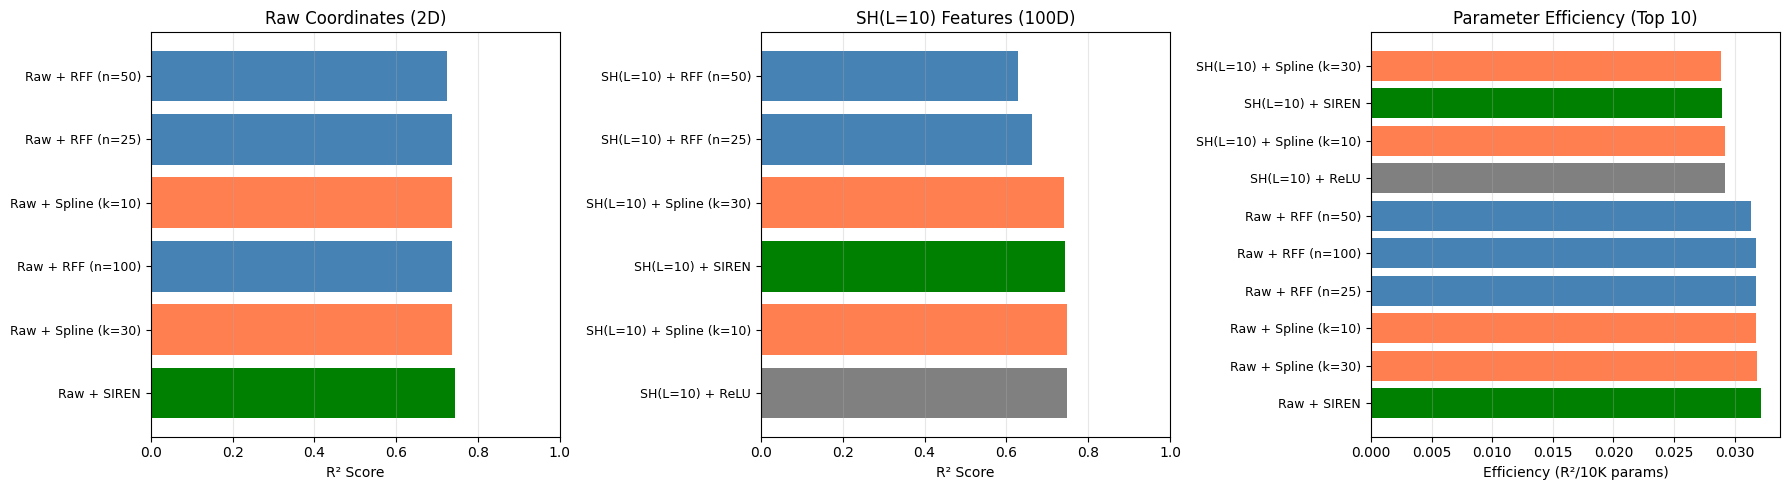

In [10]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Raw coords comparison
ax = axes[0]
raw_models = df[df['model'].str.startswith('Raw')].sort_values('r2', ascending=False)
colors_raw = ['steelblue' if 'RFF' in m else 'coral' if 'Spline' in m else 'green'
              for m in raw_models['model']]
ax.barh(range(len(raw_models)), raw_models['r2'], color=colors_raw)
ax.set_yticks(range(len(raw_models)))
ax.set_yticklabels(raw_models['model'], fontsize=9)
ax.set_xlabel('R² Score')
ax.set_title('Raw Coordinates (2D)')
ax.set_xlim(0, 1)
ax.grid(True, alpha=0.3, axis='x')

# Plot 2: SH features comparison
ax = axes[1]
sh_models = df[df['model'].str.startswith('SH')].sort_values('r2', ascending=False)
colors_sh = ['steelblue' if 'RFF' in m else 'coral' if 'Spline' in m else 'green' if 'SIREN' in m else 'gray'
             for m in sh_models['model']]
ax.barh(range(len(sh_models)), sh_models['r2'], color=colors_sh)
ax.set_yticks(range(len(sh_models)))
ax.set_yticklabels(sh_models['model'], fontsize=9)
ax.set_xlabel('R² Score')
ax.set_title('SH(L=10) Features (100D)')
ax.set_xlim(0, 1)
ax.grid(True, alpha=0.3, axis='x')

# Plot 3: Efficiency comparison
ax = axes[2]
top_models = df.nlargest(10, 'efficiency')
colors_eff = ['steelblue' if 'RFF' in m else 'coral' if 'Spline' in m else 'green' if 'SIREN' in m else 'gray'
              for m in top_models['model']]
ax.barh(range(len(top_models)), top_models['efficiency'], color=colors_eff)
ax.set_yticks(range(len(top_models)))
ax.set_yticklabels(top_models['model'], fontsize=9)
ax.set_xlabel('Efficiency (R²/10K params)')
ax.set_title('Parameter Efficiency (Top 10)')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('phase1_core_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Save results
df.to_csv('phase1_results.csv', index=False)
print("Results saved!")

print("\n" + "="*80)
print("CONCLUSIONS")
print("="*80)
print("""
Based on the 2×2 grid results:

Q1: Can learned activations discover frequencies from raw coordinates?
    → Compare Raw+RFF vs Raw+SIREN

Q2: Do learned activations provide better nonlinearity than SIREN?
    → Compare SH+RFF vs SH+SIREN

Q3: Does SH encoding help learned activations?
    → Compare Raw+RFF vs SH+RFF

Q4: What's the optimal number of RFF features or Spline knots?
    → Check n=25 vs n=50 vs n=100 and k=10 vs k=30

Next steps:
- If SH+RFF beats SH+SIREN: Try SH(L=40) combinations
- If Raw+RFF ≈ Raw+SIREN: Learned acts can discover frequencies!
- Test on other tasks (MOSAIKS, temperature, etc.)
- Add spatial gating (Phase 4 of roadmap)
""")

Results saved!

CONCLUSIONS

Based on the 2×2 grid results:

Q1: Can learned activations discover frequencies from raw coordinates?
    → Compare Raw+RFF vs Raw+SIREN

Q2: Do learned activations provide better nonlinearity than SIREN?
    → Compare SH+RFF vs SH+SIREN

Q3: Does SH encoding help learned activations?
    → Compare Raw+RFF vs SH+RFF

Q4: What's the optimal number of RFF features or Spline knots?
    → Check n=25 vs n=50 vs n=100 and k=10 vs k=30

Next steps:
- If SH+RFF beats SH+SIREN: Try SH(L=40) combinations
- If Raw+RFF ≈ Raw+SIREN: Learned acts can discover frequencies!
- Test on other tasks (MOSAIKS, temperature, etc.)
- Add spatial gating (Phase 4 of roadmap)

